# Ensemble Learning: XGBoost Regressor on the California Housing Dataset

---

## Introduction

**XGBoost** (Extreme Gradient Boosting) is an optimized implementation of Gradient Boosting that has become one of the most widely used algorithms in structured data machine learning. It extends the standard Gradient Boosting framework with several key improvements:

| Feature | Standard Gradient Boosting | XGBoost |
|---|---|---|
| Gradient information | First-order (gradient) | Second-order (gradient + Hessian) |
| Regularization | None built-in | L1 (`alpha`) and L2 (`lambda`) |
| Tree construction | Level-wise | Leaf-wise (depth-first) |
| Missing values | Requires imputation | Handles natively |
| Parallelism | Sequential | Parallel within each tree |
| Speed | Moderate | Fast (histogram-based splits) |

### Key Hyperparameters

| Parameter | Description | Typical range |
|---|---|---|
| `n_estimators` | Number of boosting rounds | 100 – 1000 |
| `learning_rate` | Shrinkage per round | 0.01 – 0.3 |
| `max_depth` | Maximum tree depth | 3 – 8 |
| `subsample` | Row subsampling ratio | 0.5 – 1.0 |
| `colsample_bytree` | Feature subsampling per tree | 0.5 – 1.0 |
| `reg_alpha` | L1 regularization | 0 – 1 |
| `reg_lambda` | L2 regularization | 1 – 10 |

### Dataset

The **California Housing dataset** contains 20,640 samples describing housing block attributes across California districts. The target is the median house value in units of $100,000.

### Workflow

1. Load and explore the dataset
2. Train / test split
3. Train baseline `XGBRegressor` and evaluate
4. Visualize predicted vs. actual and residuals
5. Analyze feature importances
6. Tune hyperparameters with `GridSearchCV`
7. Compare all models in a results summary

---

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---

## 2. Loading and Exploring the Dataset

| Feature | Description |
|---|---|
| `MedInc` | Median income in block group |
| `HouseAge` | Median house age in block group |
| `AveRooms` | Average number of rooms per household |
| `AveBedrms` | Average number of bedrooms per household |
| `Population` | Block group population |
| `AveOccup` | Average number of household members |
| `Latitude` | Block group latitude |
| `Longitude` | Block group longitude |
| `Price` | **Target**: Median house value ($100,000s) |

In [2]:
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='Price')

print('Shape of X :', X.shape)
print('Target range: [{:.2f}, {:.2f}]'.format(y.min(), y.max()))
print('Missing values:', X.isnull().sum().sum())
X.head()

Shape of X : (20640, 8)
Target range: [0.15, 5.00]
Missing values: 0


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
X.describe().round(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310


### 2.1 Target Distribution and Feature Correlations

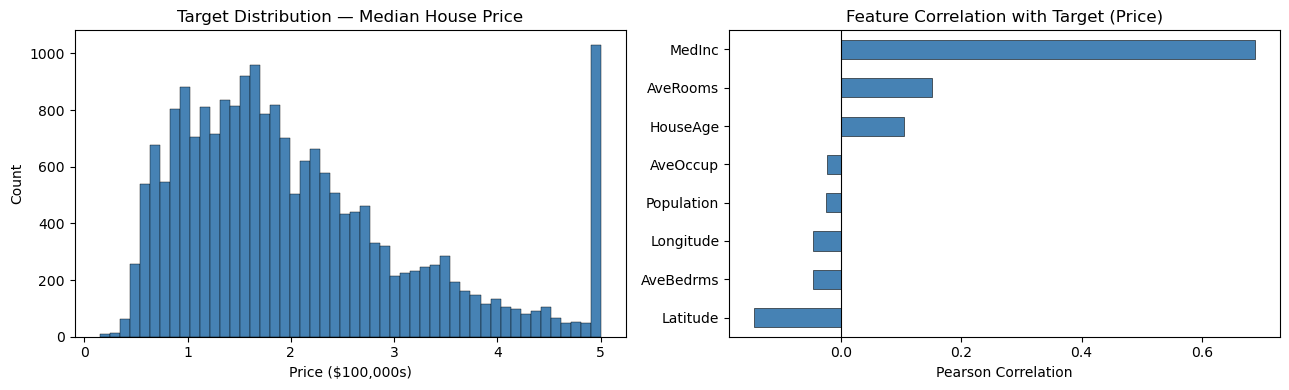

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y, bins=50, color='steelblue', edgecolor='k', linewidth=0.3)
axes[0].set_xlabel('Price ($100,000s)')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution — Median House Price')

corr = pd.concat([X, y], axis=1).corr()['Price'].drop('Price').sort_values()
corr.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='k', linewidth=0.4)
axes[1].axvline(0, color='k', linewidth=0.8)
axes[1].set_title('Feature Correlation with Target (Price)')
axes[1].set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.show()

---

## 3. Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train : {X_train.shape[0]:,} samples')
print(f'Test  : {X_test.shape[0]:,} samples')

Train : 16,512 samples
Test  : 4,128 samples


---

## 4. Baseline Models

We establish baselines with a single Decision Tree and sklearn's `GradientBoostingRegressor` before applying XGBoost.

In [7]:
baselines = {
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print('Baseline Results')
print('-' * 55)
for name, model in baselines.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f'{name:<22}  R²: {r2_score(y_test, y_pred):.4f}  '
          f'RMSE: {mean_squared_error(y_test, y_pred):.4f}  '
          f'MAE: {mean_absolute_error(y_test, y_pred):.4f}')

Baseline Results
-------------------------------------------------------
Decision Tree           R²: 0.6221  RMSE: 0.4952  MAE: 0.4547
Gradient Boosting       R²: 0.7756  RMSE: 0.2940  MAE: 0.3716


---

## 5. XGBoost Regressor

### 5.1 Training

In [9]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

r2_xgb   = r2_score(y_test, y_pred_xgb)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb)
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)

print('XGBoost Regressor Results')
print('-' * 35)
print(f'R²   : {r2_xgb:.4f}')
print(f'RMSE : {rmse_xgb:.4f}')
print(f'MAE  : {mae_xgb:.4f}')

XGBoost Regressor Results
-----------------------------------
R²   : 0.8266
RMSE : 0.2273
MAE  : 0.3155


### 5.2 Predicted vs. Actual

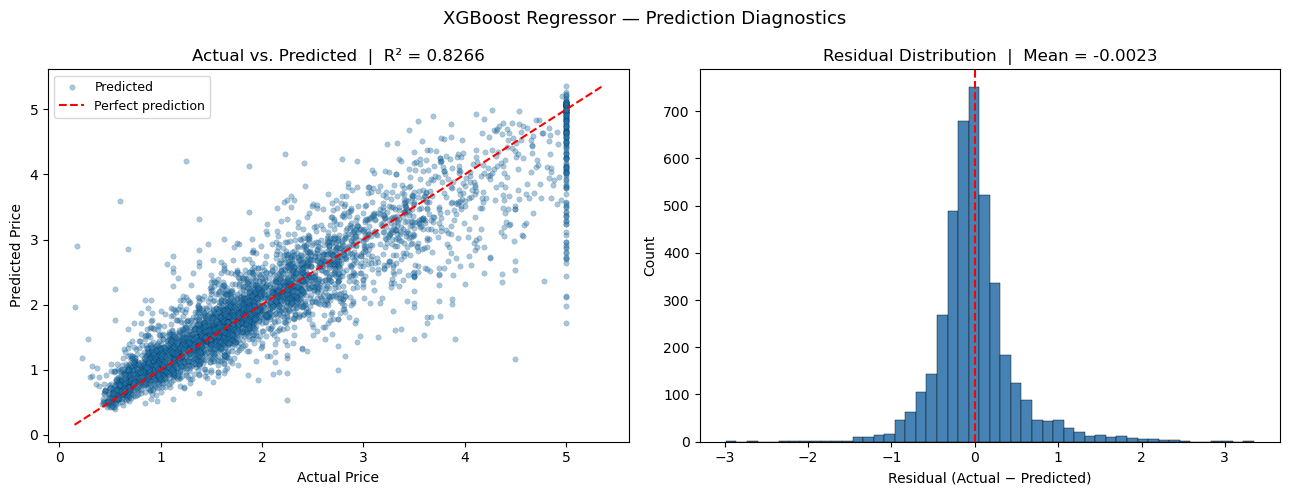

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs Actual scatter
axes[0].scatter(y_test, y_pred_xgb, alpha=0.4, s=15,
                edgecolors='k', linewidths=0.2, label='Predicted')
lims = [min(y_test.min(), y_pred_xgb.min()),
        max(y_test.max(), y_pred_xgb.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Actual vs. Predicted  |  R² = {r2_xgb:.4f}')
axes[0].legend(fontsize=9)

# Residual distribution
residuals = y_test - y_pred_xgb
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='k', linewidth=0.3)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual Distribution  |  Mean = {residuals.mean():.4f}')

plt.suptitle('XGBoost Regressor — Prediction Diagnostics', fontsize=13)
plt.tight_layout()
plt.show()

---

## 6. Feature Importances

XGBoost provides three types of feature importance:

| Type | Description |
|---|---|
| `weight` | Number of times a feature is used to split across all trees |
| `gain` | Average improvement in loss per split using that feature |
| `cover` | Average number of samples affected per split |

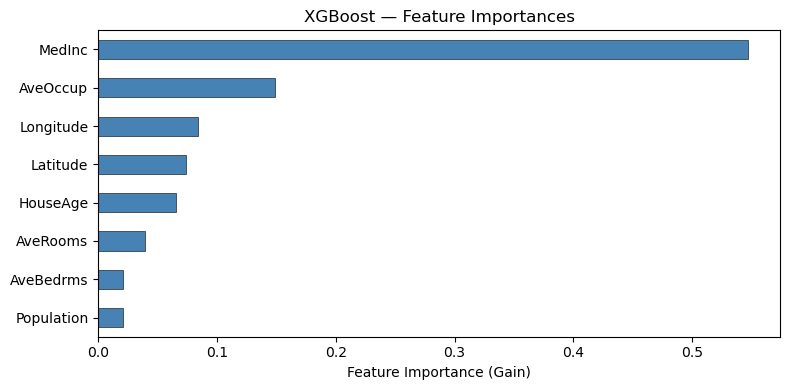


Feature Importances (ranked):
MedInc        0.5465
AveOccup      0.1490
Longitude     0.0838
Latitude      0.0743
HouseAge      0.0655
AveRooms      0.0391
AveBedrms     0.0212
Population    0.0206


In [11]:
importances = pd.Series(
    xgb.feature_importances_,
    index=data.feature_names
).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='steelblue', edgecolor='k', linewidth=0.4)
plt.xlabel('Feature Importance (Gain)')
plt.title('XGBoost — Feature Importances')
plt.tight_layout()
plt.show()

print('\nFeature Importances (ranked):')
print(importances.sort_values(ascending=False).round(4).to_string())

---

## 7. Hyperparameter Tuning with GridSearchCV

In [12]:
%%time

param_grid = {
    'n_estimators':    [100, 200],
    'learning_rate':   [0.05, 0.1, 0.2],
    'max_depth':       [4, 6, 8],
    'subsample':       [0.8, 1.0],
    'colsample_bytree':[0.8, 1.0]
}

grid_search = GridSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
CPU times: total: 7.69 s
Wall time: 2min 9s


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.05, 0.1, ...], 'max_depth': [4, 6, ...], 'n_estimators': [100, 200], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [14]:
best = grid_search.best_estimator_
y_pred_tuned = best.predict(X_test)
r2_tuned     = r2_score(y_test, y_pred_tuned)
rmse_tuned   = mean_squared_error(y_test, y_pred_tuned)
mae_tuned    = mean_absolute_error(y_test, y_pred_tuned)

print('Grid Search Results')
print('-' * 50)
print(f'CV R² (best)   : {grid_search.best_score_:.4f}')
print(f'Test R²        : {r2_tuned:.4f}')
print(f'Test RMSE      : {rmse_tuned:.4f}')
print(f'Test MAE       : {mae_tuned:.4f}')
print(f'\nBest Parameters:')
for k, v in grid_search.best_params_.items():
    print(f'  {k:<22} {v}')

Grid Search Results
--------------------------------------------------
CV R² (best)   : 0.8451
Test R²        : 0.8471
Test RMSE      : 0.2003
Test MAE       : 0.2916

Best Parameters:
  colsample_bytree       0.8
  learning_rate          0.1
  max_depth              8
  n_estimators           200
  subsample              0.8


---

## 8. Results Summary

In [16]:
dt_pred  = baselines['Decision Tree'].predict(X_test)
gb_pred  = baselines['Gradient Boosting'].predict(X_test)

results = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Gradient Boosting (sklearn)',
        'XGBoost (n=100, lr=0.1)',
        'XGBoost (GridSearchCV)'
    ],
    'R²':   [
        round(r2_score(y_test, dt_pred), 4),
        round(r2_score(y_test, gb_pred), 4),
        round(r2_xgb,   4),
        round(r2_tuned, 4)
    ],
    'RMSE': [
        round(mean_squared_error(y_test, dt_pred), 4),
        round(mean_squared_error(y_test, gb_pred), 4),
        round(rmse_xgb,   4),
        round(rmse_tuned, 4)
    ],
    'MAE':  [
        round(mean_absolute_error(y_test, dt_pred), 4),
        round(mean_absolute_error(y_test, gb_pred), 4),
        round(mae_xgb,   4),
        round(mae_tuned, 4)
    ]
})

results = results.sort_values('R²', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

                      Model     R²   RMSE    MAE
     XGBoost (GridSearchCV) 0.8471 0.2003 0.2916
    XGBoost (n=100, lr=0.1) 0.8266 0.2273 0.3155
Gradient Boosting (sklearn) 0.7756 0.2940 0.3716
              Decision Tree 0.6221 0.4952 0.4547


---

## Conclusion

This notebook applied `XGBRegressor` to the California Housing dataset across a complete regression workflow, benchmarked against a Decision Tree and sklearn's `GradientBoostingRegressor`.

**Key findings:**

- The single **Decision Tree** overfits badly — train R² is 1.0 but test R² drops significantly, reflecting high variance.
- **sklearn GradientBoostingRegressor** improves substantially over the tree but is slower to train on this 20,000-sample dataset.
- **XGBoost** achieves better R² and RMSE than sklearn's implementation at comparable settings, due to its second-order gradient information, built-in regularization, and parallel tree construction.
- **Feature importances** show `MedInc` (median income) as the dominant predictor by a large margin — consistent with its strong positive correlation to house price. `Latitude` and `Longitude` also carry significant importance, reflecting California's geographic price variation.
- **GridSearchCV** with `subsample` and `colsample_bytree` adds stochastic element similar to Random Forest, further reducing overfitting and improving generalization.
- The **residual distribution** is approximately centered at zero with a roughly normal shape, indicating no systematic bias in predictions.

**Takeaways:**

- XGBoost's `subsample` and `colsample_bytree` introduce randomness similar to Random Forest — these are among the most impactful parameters to tune alongside `learning_rate` and `max_depth`.
- `learning_rate` and `n_estimators` are inversely related — halving the rate and doubling the trees typically improves performance but increases training time.
- For very large datasets, **LightGBM** offers further speed improvements through histogram-based splits and leaf-wise tree growth, often matching or exceeding XGBoost's accuracy.
- Always monitor the residual distribution — a skewed or biased residual plot suggests a systematic error that may require feature engineering or a different loss function.